<a href="https://colab.research.google.com/github/muallacapar/BLM463-Veri-Madenciligi-Donem-Projesi/blob/main/BLM463_Veri_Madenciligi_Proje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. UCI kütüphanesini ortama yüklüyoruz (Bağlantı başındaki ünlem işareti terminal komutu olduğunu gösterir)
!pip install ucimlrepo

# 2. Gerekli kütüphaneleri projemize dahil ediyoruz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# UCI veri setini çekmek için ilgili fonksiyonu çağırıyoruz
from ucimlrepo import fetch_ucirepo

print("Kütüphaneler başarıyla yüklendi!")

Kütüphaneler başarıyla yüklendi!


In [ ]:
# Veri setini ID'si ile çekiyoruz (Buradaki fonksiyon adını fetch_ucirepo olarak düzelttik)
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# Özellikleri (Giriş parametreleri - X) ve Hedef Değişkeni (Teşhis - y) değişkenlere atıyoruz
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Verinin ilk 5 satırına göz atarak sütun yapısını inceliyoruz
print("--- Özelliklerin (X) İlk 5 Satırı ---")
display(X.head())

print("\n--- Hedef Değişkenin (y) İlk 5 Satırı ---")
display(y.head())

# Veri seti boyutu
print(f"\nVeri seti boyutu: {X.shape[0]} satır, {X.shape[1]} sütun içeriyor.")

--- Özelliklerin (X) İlk 5 Satırı ---


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



--- Hedef Değişkenin (y) İlk 5 Satırı ---


,Diagnosis
0,M
1,M
2,M
3,M
4,M



Veri seti boyutu: 569 satır, 30 sütun içeriyor.


/tmp/ipykernel_3570/565316461.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=y, palette='Set2')


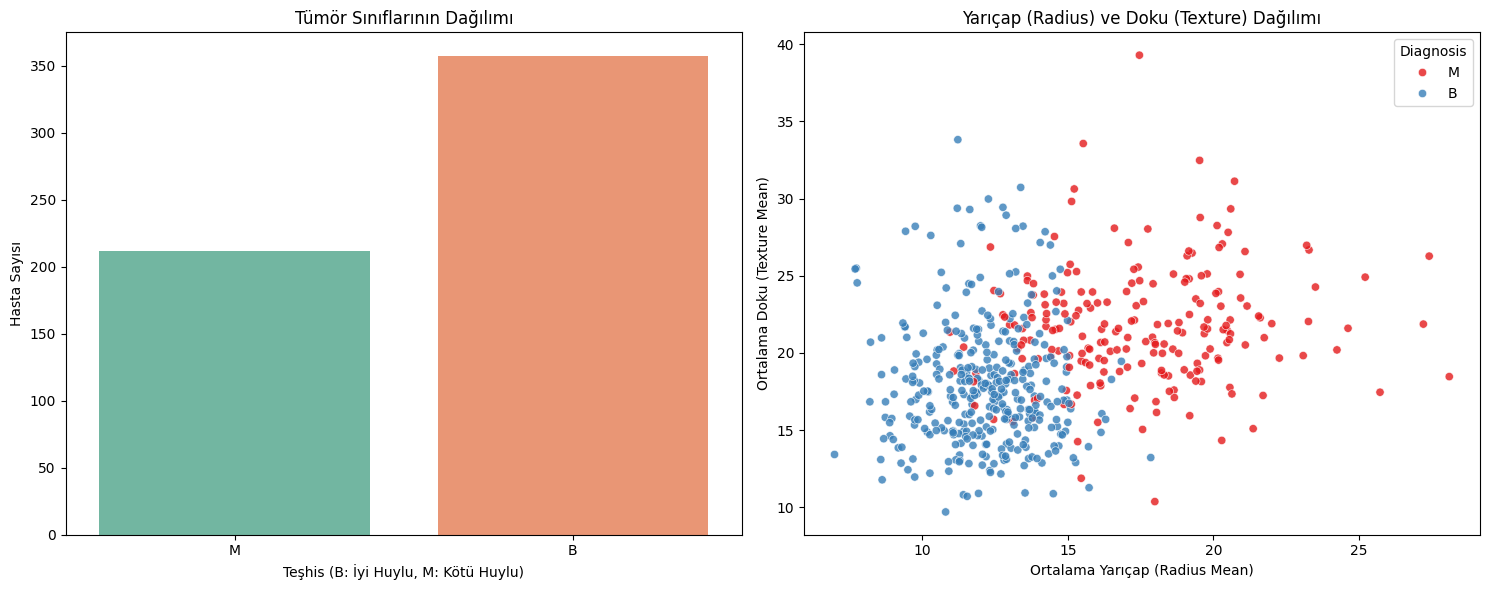

In [ ]:
# Görselleştirmelerin alt alta düzgün görünmesi için bir figür alanı oluşturuyoruz
plt.figure(figsize=(15, 6))

# Grafiği Çiziyoruz: Sınıf Dağılımı (M vs B)
plt.subplot(1, 2, 1) # 1 satır, 2 sütunlu alanın 1. grafiği
sns.countplot(x='Diagnosis', data=y, palette='Set2')
plt.title('Tümör Sınıflarının Dağılımı')
plt.xlabel('Teşhis (B: İyi Huylu, M: Kötü Huylu)')
plt.ylabel('Hasta Sayısı')

# 2. Grafiği Çiziyoruz: Örnek iki özelliğin birbiriyle ilişkisi
plt.subplot(1, 2, 2) # 1 satır, 2 sütunlu alanın 2. grafiği
# X ve y veri çerçevelerini analiz için geçici olarak birleştiriyoruz
temp_df = pd.concat([X, y], axis=1)
sns.scatterplot(x='radius1', y='texture1', hue='Diagnosis', data=temp_df, palette='Set1', alpha=0.8)
plt.title('Yarıçap (Radius) ve Doku (Texture) Dağılımı')
plt.xlabel('Ortalama Yarıçap (Radius Mean)')
plt.ylabel('Ortalama Doku (Texture Mean)')

# Grafikleri ekrana sığdır ve göster
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Adım: Hedef değişkenimizi (y) bilgisayarın anlayacağı 0 ve 1 değerlerine dönüştürüyoruz
# M (Kötü Huylu) -> 1, B (İyi Huylu) -> 0 olacak
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())

# 2. Adım: Veri setimizi Train (Eğitim) ve Test olarak ikiye bölüyoruz
# Verinin %70'ini modeli eğitmek, %30'unu ise test etmek için ayırıyoruz
# random_state=42 parametresi, kodu her çalıştırdığımızda aynı ayrımı yapmasını sağlar (tutarlılık için)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# 3. Adım: Özellik Ölçeklendirme (Feature Scaling) - SVM için en kritik adım!
scaler = StandardScaler()

# Eğitim verisini ölçeklendiriyoruz (ortalamayı ve standart sapmayı öğrenip uyguluyor)
X_train_scaled = scaler.fit_transform(X_train)

# Test verisini ise SADECE dönüştürüyoruz (eğitim verisinden öğrendiği ölçekle)
X_test_scaled = scaler.transform(X_test)

print("Veri ön işleme adımları başarıyla tamamlandı!")
print(f"Eğitim veri seti boyutu: {X_train_scaled.shape}")
print(f"Test veri seti boyutu: {X_test_scaled.shape}")

Veri ön işleme adımları başarıyla tamamlandı!
Eğitim veri seti boyutu: (398, 30)
Test veri seti boyutu: (171, 30)


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# 1. Adım: Farklı parametre kombinasyonlarını denemek için bir arama uzayı (grid) tanımlıyoruz
param_grid = {
    'C': [0.1, 1, 10, 100],             # Modelin hatalara ne kadar ceza keseceğini belirler
    'gamma': [1, 0.1, 0.01, 0.001],     # RBF çekirdeğinin etki çapını belirler
    'kernel': ['linear', 'rbf']         # Hem doğrusal hem de radyal çekirdekleri deniyoruz
}

# 2. Adım: GridSearchCV nesnesini oluşturuyoruz
# cv=5 parametresi, veriyi 5 parçaya bölüp çapraz doğrulama (5-Fold Cross Validation) yapmasını sağlar
grid = GridSearchCV(SVC(), param_grid, refit=True, cv=5, verbose=1)

# 3. Adım: Modeli eğitim verilerimizle eğitiyoruz (GridSearchCV tüm kombinasyonları tek tek dener)
grid.fit(X_train_scaled, y_train)

# 4. Adım: En iyi sonuç veren parametreleri ekrana yazdırıyoruz
print("\n--- Optimizasyon Tamamlandı! ---")
print("En İyi Parametreler:", grid.best_params_)
print("Eğitim Setindeki En İyi Doğruluk (Accuracy) Skoru: %", round(grid.best_score_ * 100, 2))

# En iyi modeli test aşamasında kullanmak üzere kaydediyoruz
best_svm_model = grid.best_estimator_

Fitting 5 folds for each of 32 candidates, totalling 160 fits

--- Optimizasyon Tamamlandı! ---
En İyi Parametreler: {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
Eğitim Setindeki En İyi Doğruluk (Accuracy) Skoru: % 97.48


     TEST VERİ SETİ PERFORMANS METRİKLERİ
Doğruluk (Accuracy)       : % 98.25
Duyarlılık (Sensitivity)   : % 96.83
Özgünlük (Specificity)     : % 99.07
F-Ölçüsü (F1-Measure)      : % 97.60
Keskinlik (Precision)      : % 98.39


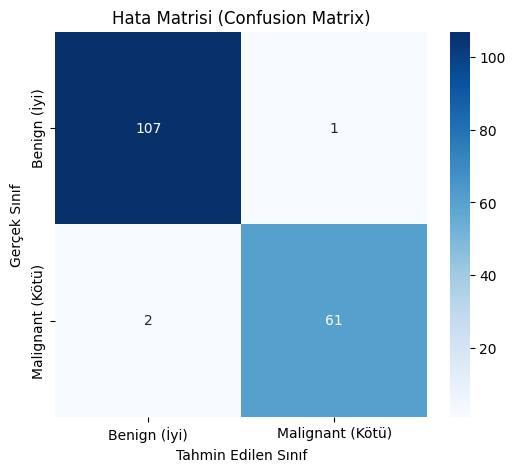

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 1. Adım: En iyi SVM modelimizi kullanarak test verileri üzerinde tahmin yapıyoruz
y_pred = best_svm_model.predict(X_test_scaled)

# 2. Adım: Hata Matrisini (Confusion Matrix) hesaplıyoruz
cm = confusion_matrix(y_test, y_pred)
# tn: True Negative (Sağlıklıya sağlıklı denmiş)
# fp: False Positive (Sağlıklıya kanserli denmiş - Yanlış Alarm)
# fn: False Negative (Kanserliye sağlıklı denmiş - EN TEHLİKELİSİ!)
# tp: True Positive (Kanserliye kanserli denmiş)
tn, fp, fn, tp = cm.ravel()

# 3. Adım: Hocanın istediği yaygın değerlendirme ölçütlerini hesaplıyoruz
accuracy = accuracy_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred) # Sensitivity ve Recall aynı şeydir
specificity = tn / (tn + fp) # Özgünlük formülü
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

# 4. Adım: Sonuçları ekrana şık bir tablo halinde yazdırıyoruz
print("==================================================")
print("     TEST VERİ SETİ PERFORMANS METRİKLERİ")
print("==================================================")
print(f"Doğruluk (Accuracy)       : % {accuracy * 100:.2f}")
print(f"Duyarlılık (Sensitivity)   : % {sensitivity * 100:.2f}")
print(f"Özgünlük (Specificity)     : % {specificity * 100:.2f}")
print(f"F-Ölçüsü (F1-Measure)      : % {f1 * 100:.2f}")
print(f"Keskinlik (Precision)      : % {precision * 100:.2f}")
print("==================================================")

# 5. Adım: Confusion Matrix'i görselleştiriyoruz
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (İyi)', 'Malignant (Kötü)'],
            yticklabels=['Benign (İyi)', 'Malignant (Kötü)'])
plt.title('Hata Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

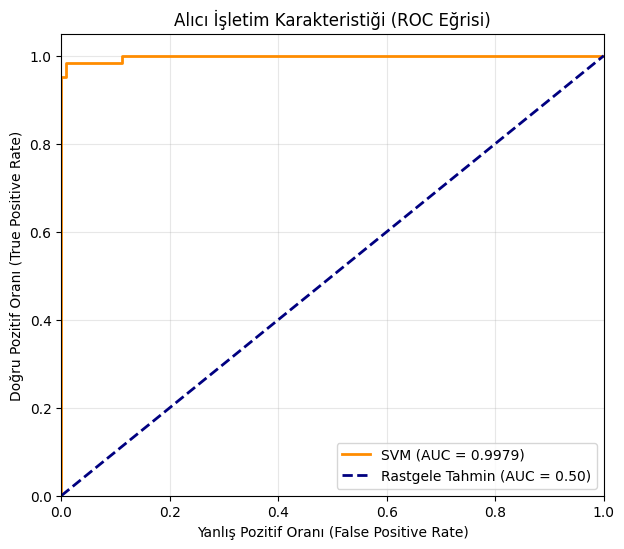

In [ ]:
from sklearn.metrics import roc_curve, auc

# 1. Adım: Modelin test seti için tahmin olasılıklarını veya karar fonksiyonu mesafelerini alıyoruz
# 'linear' kernel kullandığımız için decision_function kullanıyoruz
y_scores = best_svm_model.decision_function(X_test_scaled)

# 2. Adım: False Positive Rate (FPR) ve True Positive Rate (TPR) değerlerini hesaplıyoruz
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# 3. Adım: ROC Eğrisini çizdiriyoruz
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'SVM (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (False Positive Rate)')
plt.ylabel('Doğru Pozitif Oranı (True Positive Rate)')
plt.title('Alıcı İşletim Karakteristiği (ROC Eğrisi)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()